In [1]:
from pythtb import TBModel, WFArray, Mesh, Lattice
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define lattice vectors
lat_vecs = [[1, 0], [1 / 2, np.sqrt(3) / 2]]
# define coordinates of orbitals
orb_vecs = [[1 / 3, 1 / 3], [2 / 3, 2 / 3]]

lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=...)

# make two dimensional tight-binding boron nitride model
my_model = TBModel(lat)

# set periodic model
delta = 0.4
t = -1.0
my_model.set_onsite([-delta, delta])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])
print(my_model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
spinful                     = False
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]

Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  < 0 | H | 0 > = -0.400 
  < 1 | H | 1 > =  0.400 
Hoppings:
  < 0 | H | 1  + [ 0.0 ,  0.0 ] > = -1.0000+0.0000j
  < 1 | H | 0  + [ 1.0 , 

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

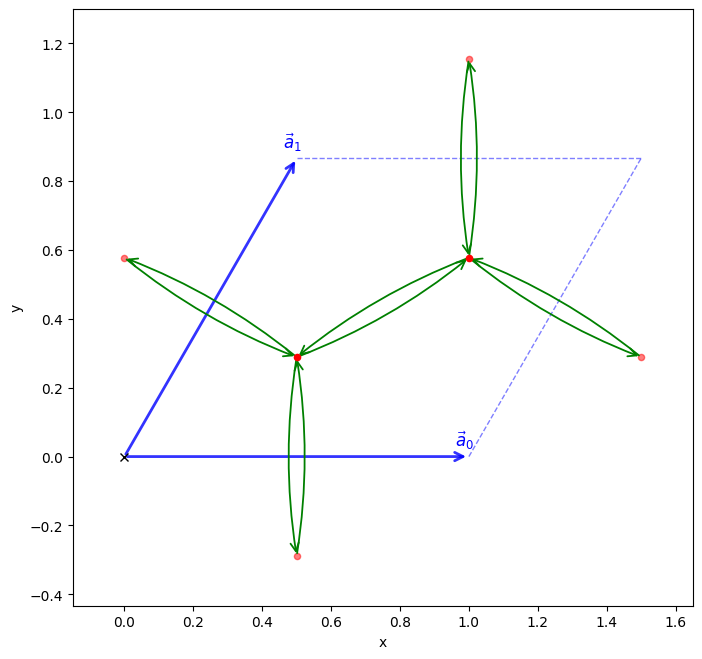

In [3]:
my_model.visualize()

In [4]:
model_orig = my_model.cut_piece(num_cells=3, periodic_dir=1, glue_edges=False)
print(model_orig)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 1
periodic directions         = [0]
spinful                     = False
number of spin components   = 1
number of electronic states = 6
number of orbitals          = 6

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283,  0.000]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
  # 2 ===> [ 1.000,  1.155]
  # 3 ===> [ 1.500,  1.443]
  # 4 ===> [ 1.500,  2.021]
  # 5 ===> [ 2.000,  2.309]

Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
  # 2 ===> [ 0.333,  1.333]
  # 3 ===> [ 0.667,  1.667]
  # 4 ===> [ 0.333,  2.333]
  # 5 ===> [ 0.667,  2.667]
---

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

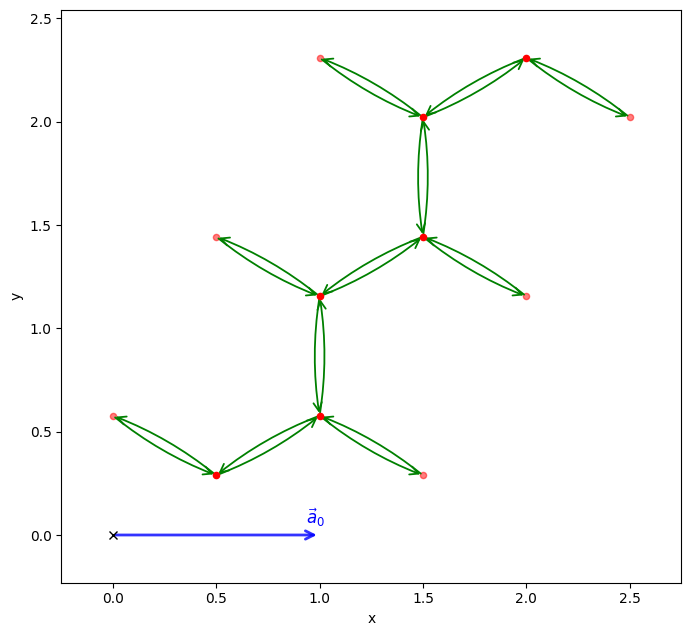

In [5]:
model_orig.visualize()

In [6]:
model_perp = model_orig.copy()
model_perp.change_nonperiodic_vector(fin_dir=1, to_home=True)

print(model_perp)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 1
periodic directions         = [0]
spinful                     = False
number of spin components   = 1
number of electronic states = 6
number of orbitals          = 6

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.000,  1.000]
Volume of unit cell (Cartesian) = 1.000 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283,  0.000]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 0.000,  0.577]
  # 2 ===> [ 0.000,  1.155]
  # 3 ===> [ 0.500,  1.443]
  # 4 ===> [ 0.500,  2.021]
  # 5 ===> [ 0.000,  2.309]

Orbital vectors (fractional):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 0.000,  0.577]
  # 2 ===> [ 0.000,  1.155]
  # 3 ===> [ 0.500,  1.443]
  # 4 ===> [ 0.500,  2.021]
  # 5 ===> [ 0.000,  2.309]
---

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

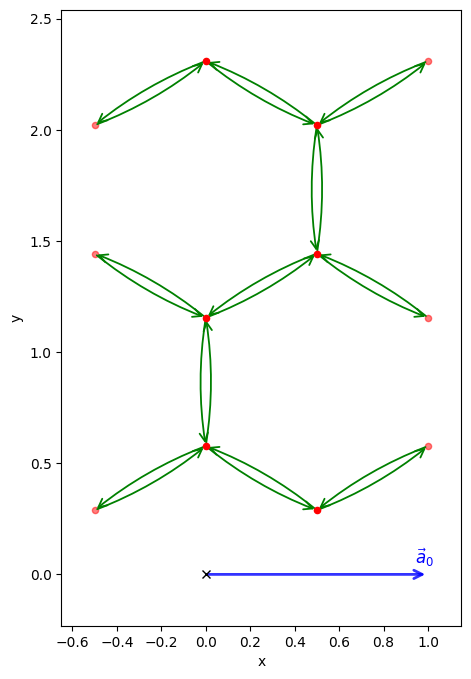

In [7]:
model_perp.visualize()

Berry Phase Original = -0.4425504
Berry Phase Shifted = -0.0000000


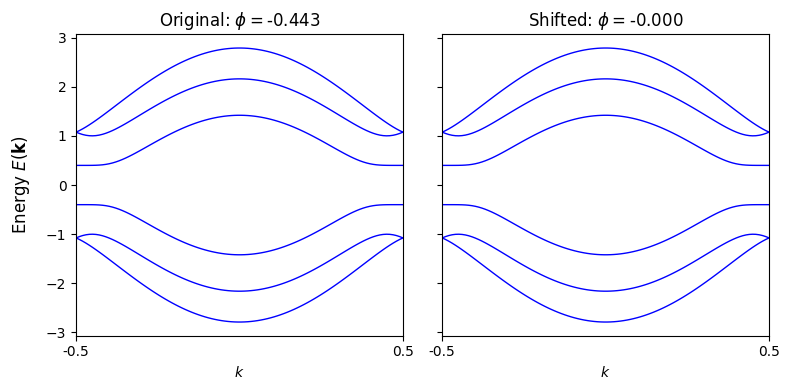

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)


def run_model(model, panel, title):
    k_nodes = [[-0.5], [0.5]]

    model.plot_bands(k_nodes=k_nodes, nk=100, fig=fig, ax=ax[panel], lw=1)
    ax[panel].set_xticklabels([-0.5, 0.5])

    mesh = Mesh(axis_types=["k"], dim_k=model.dim_k)
    mesh.build_grid(shape=(40,), gamma_centered=True)
    wf = WFArray(model.lattice, mesh)
    wf.solve_model(model)

    n_occ = model.nstate // 2
    berry_phase = wf.berry_phase(axis_idx=0, state_idx=range(n_occ))
    ax[panel].set_title(rf"{title}: $\phi=${berry_phase: .3f}")
    ax[panel].set_xlabel(r"$k$")

    print(f"Berry Phase {title} = {berry_phase:.7f}")


run_model(model_orig, 0, "Original")
run_model(model_perp, 1, "Shifted")

ax[1].set_ylabel(None)
fig.tight_layout()
plt.show()